In [1]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import os
import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import thermoift.PLOT_SETTINGS as ps
import feos

from thermoift.FeosPlugin               import (RegistryManager, ParameterBuilder, VLECalculator, CompositionHandler)
from sklearn.preprocessing              import StandardScaler
from sklearn.pipeline                   import Pipeline
from sklearn.gaussian_process           import GaussianProcessRegressor
from sklearn.gaussian_process.kernels   import Matern, ConstantKernel, WhiteKernel

RegistryManager.load_registry()


({'carbon dioxide': PureRecord(identifier: {cas: 124-38-9, name: carbon dioxide, iupac_name: carbon dioxide}, molarweight: 44.01, m: 1.6298, sigma: 3.0867, epsilon_k: 163.34, q: 3.9546),
  'hydrogen': PureRecord(identifier: {cas: 1333-74-0, name: hydrogen, iupac_name: molecular hydrogen}, molarweight: 2.016, m: 0.68, sigma: 3.54, epsilon_k: 31.57),
  'nitrogen': PureRecord(identifier: {cas: 7727-37-9, name: nitrogen, iupac_name: molecular nitrogen}, molarweight: 28.01, m: 1.1879, sigma: 3.3353, epsilon_k: 90.99, q: 1.1151, association_sites: [{nb: 2.0}]),
  'argon': PureRecord(identifier: {cas: 7440-37-1, name: argon, iupac_name: argon}, molarweight: 39.962, m: 1.0, sigma: 3.37751, epsilon_k: 117.80903),
  'methane': PureRecord(identifier: {cas: 74-82-8, name: methane, iupac_name: methane}, molarweight: 16.031, m: 1.0, sigma: 3.70051, epsilon_k: 150.07147),
  'oxygen': PureRecord(identifier: {cas: 7782-44-7, name: oxygen, iupac_name: molecular oxygen}, molarweight: 31.99, m: 1.14702, s

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG  —  GPR_AL_V2_AL (multi-T, A4 dataset, AL-only, 4 sizes, 20 trials)
# ═══════════════════════════════════════════════════════════════════════════════

POOL_PATH = "../POOL/composition_pool.csv"
A4_PATH   = "../../DATASET_A4/CombinedDataset_A4.csv"

# 5 K temperature grid from 200 K to 280 K — 17 temperatures.
# Joint pool: 1000 compositions × 17 T = 17,000 rows.
T_GRID    = [float(T) for T in range(200, 281, 5)]
T_WINDOW  = 1.0    # ±1 K, narrower than the 5 K grid spacing

# Target sample sizes — u_t(N) is auto-calibrated below
N_SIZES   = [25, 50, 75, 100]
N_MAX     = max(N_SIZES)

# 20 independent trial seeds
N_TRIALS    = 20
BASE_SEED   = 770077
TRIAL_SEEDS = [BASE_SEED + 1000 * i for i in range(N_TRIALS)]

# GPR fitting hyper-params (one-time, reused across trials)
GPR_MAX_SAMPLES   = 5000
RESTART_OPTIMIZER = 3
GPR_SEED          = BASE_SEED

OUTPUT_DIR = "AL_V2_AL"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"T_GRID    : {T_GRID} K  ({len(T_GRID)} temperatures)")
print(f"Joint pool: 1000 compositions × {len(T_GRID)} T = {1000*len(T_GRID):,} rows")
print(f"N_SIZES   : {N_SIZES}")
print(f"N_TRIALS  : {N_TRIALS}")


T_GRID    : [200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0] K  (17 temperatures)
Joint pool: 1000 compositions × 17 T = 17,000 rows
N_SIZES   : [25, 50, 75, 100]
N_TRIALS  : 20


In [3]:
# ── Column-name bridge — feature vector is (z, T) ∈ R^9 ────────────────────────
CSV_TO_FULL = {
    "CO2" : "carbon dioxide",
    "H2"  : "hydrogen",
    "Ar"  : "argon",
    "N2"  : "nitrogen",
    "CH4" : "methane",
    "O2"  : "oxygen",
    "CO"  : "carbon monoxide",
    "H2S" : "hydrogen sulfide",
}
POOL_Z_COLS = list(CSV_TO_FULL.keys())
Z_FEATURES  = [f"z_{v}" for v in CSV_TO_FULL.values()]
COMP_MAP    = {k: f"z_{v}" for k, v in CSV_TO_FULL.items()}

FEATURES    = Z_FEATURES + ["temperature"]
TARGET      = "P_bubble"
TARGET_UNIT = "bar"

print(f"GPR features : {FEATURES}  ({len(FEATURES)} total)")


GPR features : ['z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide', 'temperature']  (9 total)


In [4]:
# ── Load candidate pool ────────────────────────────────────────────────────────
pool = pd.read_csv(POOL_PATH)
print(f"Pool loaded: {len(pool):,} compositions")
print(pool.head(3))


Pool loaded: 1,000 compositions
   feed_id         feed_source template_name  mixture_size  \
0        0  Random (Dirichlet)     dirichlet             4   
1        1  Random (Dirichlet)     dirichlet             3   
2        2  Random (Dirichlet)     dirichlet             6   

     active_components   CO2        H2        Ar       N2       CH4        O2  \
0        CO2,Ar,N2,H2S  0.97  0.000000  0.005316  0.00397  0.000000  0.000000   
1            CO2,Ar,O2  0.98  0.000000  0.000874  0.00000  0.000000  0.019126   
2  CO2,H2,Ar,CH4,O2,CO  0.95  0.007078  0.008244  0.00000  0.001661  0.029273   

         CO       H2S  
0  0.000000  0.020713  
1  0.000000  0.000000  
2  0.003745  0.000000  


In [5]:
# ── Load A4, filter to 8-component rows near T_GRID, fit joint (z,T) GPR ──────
a4 = pd.read_csv(A4_PATH); a4.columns = [c.strip() for c in a4.columns]

extra_z = [c for c in a4.columns if c.startswith("z_") and c not in Z_FEATURES]
if extra_z:
    a4 = a4[a4[extra_z].sum(axis=1) < 1e-6].copy()
    print(f"8-component rows: {len(a4):,}")

T_mask = np.zeros(len(a4), dtype=bool)
for T in T_GRID:
    T_mask |= np.abs(a4["temperature"] - T) <= T_WINDOW
a4_ref = a4[T_mask].copy()
if len(a4_ref) < 100:
    print(f"Only {len(a4_ref)} rows near T_GRID — using all temperatures")
    a4_ref = a4.copy()

print(f"A4 rows near T_GRID: {len(a4_ref):,}")
for T in T_GRID:
    n = (np.abs(a4_ref["temperature"] - T) <= T_WINDOW).sum()
    print(f"  T={int(T)} K : {n:,} rows")

df_train = (a4_ref[Z_FEATURES + ["temperature", TARGET]]
              .drop_duplicates(subset=Z_FEATURES + ["temperature"])
              .dropna(subset=[TARGET])
              .reset_index(drop=True))
if len(df_train) > GPR_MAX_SAMPLES:
    df_train = df_train.sample(n=GPR_MAX_SAMPLES, random_state=GPR_SEED).reset_index(drop=True)

print(f"\nGPR training set : {len(df_train):,} labelled (composition, T) rows")
print(f"P_bubble range   : {df_train[TARGET].min():.2f} – {df_train[TARGET].max():.2f} bar")

n_feat = len(FEATURES)
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * Matern(nu=2.5, length_scale=np.ones(n_feat), length_scale_bounds=(1e-3, 1e3))
    + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 100.0))
)
gpr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr",    GaussianProcessRegressor(
        kernel=kernel, alpha=0.0, normalize_y=True,
        n_restarts_optimizer=RESTART_OPTIMIZER, random_state=GPR_SEED)),
])

t0 = time.perf_counter()
gpr_model.fit(df_train[FEATURES], df_train[TARGET])
print(f"\nGPR fitting time : {time.perf_counter()-t0:.1f} s")


A4 rows near T_GRID: 16,931
  T=200 K : 980 rows
  T=205 K : 981 rows
  T=210 K : 993 rows
  T=215 K : 987 rows
  T=220 K : 998 rows
  T=225 K : 994 rows
  T=230 K : 999 rows
  T=235 K : 999 rows
  T=240 K : 1,000 rows
  T=245 K : 1,000 rows
  T=250 K : 1,000 rows
  T=255 K : 1,000 rows
  T=260 K : 1,000 rows
  T=265 K : 1,000 rows
  T=270 K : 1,000 rows
  T=275 K : 1,000 rows
  T=280 K : 1,000 rows

GPR training set : 1,683 labelled (composition, T) rows
P_bubble range   : 3.34 – 162.88 bar

GPR fitting time : 413.7 s


/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [6]:
# ── GPR diagnostics + ARD feature importances ─────────────────────────────────
signal_kernel = gpr_model.named_steps["gpr"].kernel_.k1
sigma_f_sq    = float(signal_kernel.k1.constant_value)
scaler        = gpr_model.named_steps["scaler"]

print("Fitted kernel:"); print(f"  {gpr_model.named_steps['gpr'].kernel_}")
print(f"σ_f²* = {sigma_f_sq:.4f}")

ls  = signal_kernel.k2.length_scale
imp = 1.0 / ls;  imp /= imp.sum()
print("\nARD feature importances (1 / length-scale, normalised):")
for name, val in sorted(zip(FEATURES, imp), key=lambda x: -x[1]):
    bar = "█" * max(1, int(val * 40))
    print(f"  {name:<25s}  {val*100:5.1f}%  {bar}")

y_pred, _ = gpr_model.predict(df_train[FEATURES], return_std=True)
res = df_train[TARGET].values - y_pred
print(f"\nTrain RMSE : {np.sqrt(np.mean(res**2)):.3f} bar")
print(f"Train R²   : {1 - np.var(res)/np.var(df_train[TARGET].values):.4f}")


Fitted kernel:
  31.6**2 * Matern(length_scale=[356, 40.6, 303, 324, 594, 1e+03, 916, 65.2, 10.8], nu=2.5) + WhiteKernel(noise_level=0.0001)
σ_f²* = 1000.0000

ARD feature importances (1 / length-scale, normalised):
  temperature                 63.7%  █████████████████████████
  z_hydrogen                  16.9%  ██████
  z_hydrogen sulfide          10.5%  ████
  z_argon                      2.3%  █
  z_nitrogen                   2.1%  █
  z_carbon dioxide             1.9%  █
  z_methane                    1.2%  █
  z_carbon monoxide            0.7%  █
  z_oxygen                     0.7%  █

Train RMSE : 0.033 bar
Train R²   : 1.0000


In [7]:
# ── Expand pool × T_GRID → joint (composition, temperature) pool ──────────────
pool_renamed = pool.rename(columns=COMP_MAP)
blocks = []
for T in T_GRID:
    blk = pool_renamed[Z_FEATURES].copy()
    blk["temperature"] = T
    blocks.append(blk)
pool_joint = pd.concat(blocks, ignore_index=True)

pool_size         = len(pool)
joint_to_pool_idx = np.tile(np.arange(pool_size), len(T_GRID))
joint_to_T        = np.repeat(T_GRID, pool_size)

X_pool = scaler.transform(pool_joint[FEATURES].values)

print(f"Joint pool : {X_pool.shape}   (1000 × {len(T_GRID)} = {len(X_pool):,} rows)")
print(f"k(x,x) mean (first 5): {signal_kernel.diag(X_pool[:5]).mean():.4f}  (≈ σ_f²*)")


Joint pool : (17000, 9)   (1000 × 17 = 17,000 rows)
k(x,x) mean (first 5): 1000.0000  (≈ σ_f²*)


/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
# ── Auto-calibrate u_t(N) on the joint multi-T pool ──────────────────────────
def greedy_trace(X_all, kernel, n_max, seed):
    rng    = np.random.default_rng(seed)
    n_pool = len(X_all)
    s_list = list(rng.choice(n_pool, size=2, replace=False))
    p_set  = set(range(n_pool)) - set(s_list)
    u_pick = [np.nan, np.nan]
    while p_set and len(s_list) < n_max:
        p_list = list(p_set)
        K_TT_d = kernel.diag(X_all[p_list])
        K_TS   = kernel(X_all[p_list], X_all[s_list])
        K_SS   = kernel(X_all[s_list], X_all[s_list]) + 1e-8 * np.eye(len(s_list))
        L      = np.linalg.cholesky(K_SS)
        V      = np.linalg.solve(L, K_TS.T)
        U      = np.maximum(K_TT_d - np.einsum("ij,ij->j", V, V), 0.0)
        best   = int(np.argmax(U))
        s_list.append(p_list[best])
        u_pick.append(float(U[best]))
        p_set.discard(p_list[best])
    return s_list, np.asarray(u_pick)


print("Running one-shot greedy trace for u_t calibration …")
t0 = time.perf_counter()
_, u_trace = greedy_trace(X_pool, signal_kernel, N_MAX + 5, BASE_SEED)
print(f"  trace done in {time.perf_counter()-t0:.1f} s   "
      f"(U at step 2 = {u_trace[2]:.3e},  U at step {N_MAX} = {u_trace[N_MAX]:.3e})")

U_T_BY_N = {}
for N in N_SIZES:
    u_lo, u_hi = u_trace[N], u_trace[N - 1]
    U_T_BY_N[N] = 0.01 * float(np.sqrt(u_lo * u_hi)) if (u_lo > 0 and u_hi > 0) else float(u_lo)

print("\nAuto-calibrated u_t per N:")
for N in N_SIZES:
    print(f"  N={N:3d}   u_t = {U_T_BY_N[N]:.3e}")


Running one-shot greedy trace for u_t calibration …
  trace done in 3.6 s   (U at step 2 = 8.326e+01,  U at step 100 = 5.554e-04)

Auto-calibrated u_t per N:
  N= 25   u_t = 2.936e-04
  N= 50   u_t = 3.485e-05
  N= 75   u_t = 1.133e-05
  N=100   u_t = 5.562e-06


In [9]:
# ── Algorithm 1 — kernel-based active learning ────────────────────────────────
def compute_U_T(X_T, X_S, kernel):
    K_TT_diag = kernel.diag(X_T)
    K_TS      = kernel(X_T, X_S)
    K_SS      = kernel(X_S, X_S) + 1e-8 * np.eye(len(X_S))
    L = np.linalg.cholesky(K_SS)
    V = np.linalg.solve(L, K_TS.T)
    return np.maximum(K_TT_diag - np.einsum("ij,ij->j", V, V), 0.0)


def run_algorithm1(X_all, kernel, n_max, u_t, seed, n_t=None):
    rng    = np.random.default_rng(seed)
    n_pool = len(X_all)
    s_list = list(rng.choice(n_pool, size=2, replace=False))
    p_set  = set(range(n_pool)) - set(s_list)

    while p_set and len(s_list) < n_max:
        p_list = list(p_set)
        if n_t is not None and len(p_list) > n_t:
            t_idx  = rng.choice(len(p_list), size=n_t, replace=False)
            t_list = [p_list[i] for i in t_idx]
        else:
            t_list = p_list

        U = compute_U_T(X_all[t_list], X_all[s_list], kernel)
        best = int(np.argmax(U))
        if U[best] > u_t:
            s_list.append(t_list[best])
            p_set.discard(t_list[best])
        for i, idx in enumerate(t_list):
            if U[i] < u_t:
                p_set.discard(idx)
    return s_list


print("Running AL on joint pool: 20 trials × |N_SIZES| runs …")
t0 = time.perf_counter()
al_selections = {}
al_warnings   = []

for tr, seed in enumerate(TRIAL_SEEDS):
    for N in N_SIZES:
        sel = run_algorithm1(
            X_all  = X_pool,
            kernel = signal_kernel,
            n_max  = N,
            u_t    = U_T_BY_N[N],
            seed   = seed,
        )
        if len(sel) != N:
            al_warnings.append((tr, seed, N, len(sel), U_T_BY_N[N]))
        al_selections[(tr, N)] = sel
    if (tr + 1) % 5 == 0:
        print(f"  trial {tr+1:2d}/{N_TRIALS} done")

elapsed_al = time.perf_counter() - t0
print(f"\nAL trials done in {elapsed_al:.1f} s")
if al_warnings:
    print(f"⚠  {len(al_warnings)} (trial, N) pairs missed the target size:")
    for tr, seed, N, got, u in al_warnings[:10]:
        print(f"  trial {tr:2d} seed={seed}  N={N:3d}  got={got:3d}  u_t={u:.2e}")
    print("→ Halve the offending U_T_BY_N entries (Cell 7) and rerun Cell 8.")
else:
    print("All AL trials reached the target N exactly. ✓")


Running AL on joint pool: 20 trials × |N_SIZES| runs …
  trial  5/20 done
  trial 10/20 done
  trial 15/20 done
  trial 20/20 done

AL trials done in 111.0 s
All AL trials reached the target N exactly. ✓


In [10]:
# ── PC-SAFT P_bubble for every unique (pool_idx, T) pair across all trials ───
ALL_COMPS_FULL = [CSV_TO_FULL[k] for k in POOL_Z_COLS]

def compute_pbubble_single(z_arr, T_K):
    active_z, active_comps, _ = CompositionHandler.reduce_components(
        z_arr, ALL_COMPS_FULL, verbose=False)
    params = ParameterBuilder.build_parameters(active_comps)
    func   = feos.HelmholtzEnergyFunctional.pcsaft(params)
    feed   = CompositionHandler.compute_feed_moles(active_z)
    T_bub, P_bub = VLECalculator.compute_bubble_curve(
        func, [T_K], feed, verbose=False)
    return float(P_bub[0]) if len(P_bub) else float("nan")


needed_pairs = set()
for sel in al_selections.values():
    for ji in sel:
        needed_pairs.add((int(joint_to_pool_idx[ji]), float(joint_to_T[ji])))
needed_pairs = sorted(needed_pairs)
print(f"Unique (composition, T) pairs to evaluate: {len(needed_pairs)}")

pbubble_cache = {}
n_failed = 0
t0 = time.perf_counter()
for i, (pidx, T) in enumerate(needed_pairs):
    row   = pool.iloc[pidx]
    z_arr = np.array([row[k] for k in POOL_Z_COLS])
    try:
        p = compute_pbubble_single(z_arr, T)
    except Exception as e:
        if n_failed < 3:
            print(f"  [warn] pool[{pidx}] T={int(T)} K: {e}")
        p = float("nan"); n_failed += 1
    pbubble_cache[(pidx, T)] = p
    if (i + 1) % 50 == 0:
        print(f"  {i+1:5d}/{len(needed_pairs)}  ({n_failed} failed)")
elapsed_pb = time.perf_counter() - t0
n_ok = sum(1 for v in pbubble_cache.values() if not np.isnan(v))
print(f"\nP_bubble computed: {n_ok}/{len(needed_pairs)} OK, {n_failed} failed")
print(f"Time: {elapsed_pb:.1f} s  ({elapsed_pb/max(len(needed_pairs),1):.2f} s/pair)")


Unique (composition, T) pairs to evaluate: 710
     50/710  (0 failed)
    100/710  (0 failed)
    150/710  (0 failed)
    200/710  (0 failed)
    250/710  (0 failed)
    300/710  (0 failed)
    350/710  (0 failed)
    400/710  (0 failed)
    450/710  (0 failed)
    500/710  (0 failed)
    550/710  (0 failed)
    600/710  (0 failed)
    650/710  (0 failed)
    700/710  (0 failed)

P_bubble computed: 710/710 OK, 0 failed
Time: 12.5 s  (0.02 s/pair)


In [11]:
# ── Build per-(trial, N) AL DataFrames ────────────────────────────────────────
def make_selection_df(joint_idx_list, pool_df, pbubble_cache, j2pidx, j2T):
    rows = []
    for ji in joint_idx_list:
        pidx = int(j2pidx[ji])
        T    = float(j2T[ji])
        r    = pool_df.iloc[pidx].to_dict()
        r["pool_idx"]    = pidx
        r["temperature"] = T
        r["P_bubble"]    = pbubble_cache.get((pidx, T), float("nan"))
        rows.append(r)
    return pd.DataFrame(rows).reset_index(drop=True)


al_df = {}
for (tr, N), idx_list in al_selections.items():
    al_df[(tr, N)] = make_selection_df(
        idx_list, pool, pbubble_cache, joint_to_pool_idx, joint_to_T)
print(f"AL DataFrames built: {len(al_df)} entries")


AL DataFrames built: 80 entries


In [12]:
# ── Trial-aggregated metrics (mean ± std over the 20 trials) ─────────────────
def metric(df, name):
    if name == "mean_Pbubble":   return df["P_bubble"].mean()
    if name == "std_CO2":        return df["CO2"].std()
    if name == "median_Pbubble": return df["P_bubble"].median()
    if name == "T_unique":       return df["temperature"].nunique()
    raise ValueError(name)

metric_names = ["mean_Pbubble", "std_CO2", "median_Pbubble", "T_unique"]

records = []
for N in N_SIZES:
    for m in metric_names:
        vals = [metric(al_df[(tr, N)], m) for tr in range(N_TRIALS)]
        records.append({
            "N": N, "metric": m,
            "mean":  np.nanmean(vals),
            "std":   np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0,
            "min":   np.nanmin(vals),
            "max":   np.nanmax(vals),
        })
metrics_df = pd.DataFrame(records)
print(metrics_df.to_string(index=False))


  N         metric      mean      std       min       max
 25   mean_Pbubble 84.396582 2.952736 78.991198 90.591316
 25        std_CO2  0.013323 0.001224  0.010360  0.014892
 25 median_Pbubble 54.913760 4.182844 47.253002 63.460766
 25       T_unique  8.800000 1.239694  6.000000 11.000000
 50   mean_Pbubble 87.149444 2.320131 83.406873 91.929010
 50        std_CO2  0.012301 0.000775  0.010885  0.013946
 50 median_Pbubble 61.963581 2.576543 57.571170 69.461595
 50       T_unique 14.000000 1.169795 11.000000 16.000000
 75   mean_Pbubble 87.370273 1.506847 84.723862 91.696462
 75        std_CO2  0.011928 0.000508  0.010934  0.013224
 75 median_Pbubble 64.448949 2.280508 60.408511 70.511919
 75       T_unique 16.400000 0.820783 15.000000 17.000000
100   mean_Pbubble 86.872184 1.856849 83.244614 91.848075
100        std_CO2  0.011552 0.000516  0.010773  0.012506
100 median_Pbubble 64.648582 2.035516 60.504191 71.066396
100       T_unique 16.900000 0.447214 15.000000 17.000000


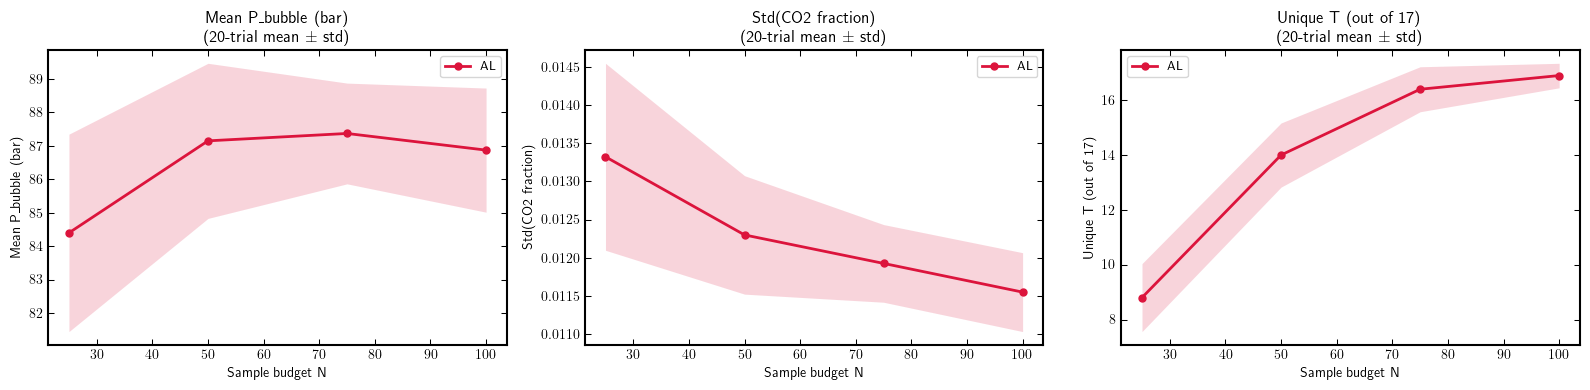

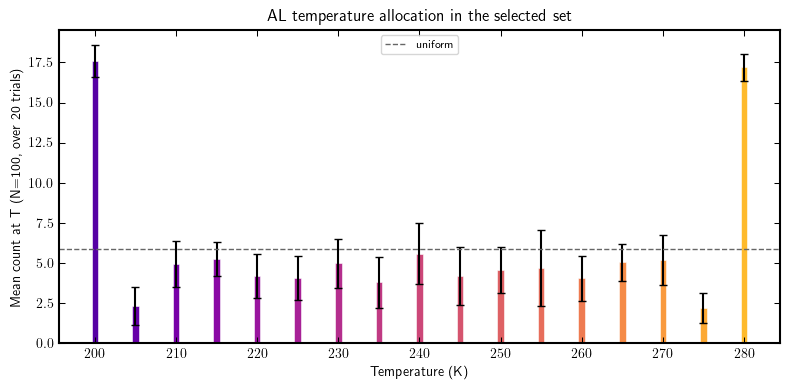

In [13]:
# ── AL learning-curve plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, mname, ylab in zip(
        axes,
        ["mean_Pbubble",        "std_CO2",            "T_unique"],
        ["Mean P_bubble (bar)", "Std(CO2 fraction)",  f"Unique T (out of {len(T_GRID)})"]):
    sub = metrics_df[metrics_df["metric"] == mname].sort_values("N")
    ax.plot(sub["N"], sub["mean"], color="crimson", lw=2, marker="o", ms=5, label="AL")
    ax.fill_between(sub["N"], sub["mean"] - sub["std"], sub["mean"] + sub["std"],
                    color="crimson", alpha=0.18, lw=0)
    ax.set_xlabel("Sample budget N")
    ax.set_ylabel(ylab)
    ax.set_title(f"{ylab}\n(20-trial mean ± std)")
    ax.legend(fontsize=9)
    ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig, "AL_V2_AL_learning_curves", folder=OUTPUT_DIR)
plt.show()


fig2, ax = plt.subplots(figsize=(8, 4))
T_colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(T_GRID)))
means, stds = [], []
for T in T_GRID:
    per_trial = [(al_df[(tr, N_MAX)]["temperature"] == T).sum() for tr in range(N_TRIALS)]
    means.append(np.mean(per_trial))
    stds.append(np.std(per_trial, ddof=1))
ax.bar([int(T) for T in T_GRID], means, yerr=stds, capsize=3,
       color=T_colors, edgecolor="white", linewidth=0.4)
ax.axhline(N_MAX / len(T_GRID), ls="--", color="0.4", lw=1, label="uniform")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel(f"Mean count at T  (N={N_MAX}, over {N_TRIALS} trials)")
ax.set_title("AL temperature allocation in the selected set")
ax.legend(fontsize=8)
ps.apply_axis_style(ax)
plt.tight_layout()
ps.save_plot(fig2, "AL_V2_AL_T_allocation", folder=OUTPUT_DIR)
plt.show()


In [14]:
# ── Save outputs: per-trial CSVs + aggregated metrics + GPR model ────────────
# Layout expected by RUN_trial.sh + clean_trials.ipynb:
#   {METHOD}/OUTPUT/N{XXX}/trial_{NN}.csv
for (tr, N), df in al_df.items():
    out_dir = os.path.join(OUTPUT_DIR, "OUTPUT", f"N{N:03d}")
    os.makedirs(out_dir, exist_ok=True)
    df.to_csv(os.path.join(out_dir, f"trial_{tr:02d}.csv"), index=False)

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "AL_metrics_trial_aggregated.csv"), index=False)
joblib.dump(gpr_model, os.path.join(OUTPUT_DIR, "GPR_AL_V2_AL_model.joblib"))
print(f"Saved {len(al_df)} per-trial CSVs + metrics + GPR model → {OUTPUT_DIR}")


Saved 80 per-trial CSVs + metrics + GPR model → AL_V2_AL


In [15]:
elapsed_total = (time.perf_counter() - notebook_start) / 60
print(f"Total notebook runtime : {elapsed_total:.1f} min")
print(f"  AL trials   : {elapsed_al:.1f} s")
print(f"  PC-SAFT     : {elapsed_pb:.1f} s")


Total notebook runtime : 9.4 min
  AL trials   : 111.0 s
  PC-SAFT     : 12.5 s
